<a href="https://colab.research.google.com/github/realcoli/previsao-diabetes-machine-learning/blob/main/previsao_diabetes_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Previsão de Diabetes com Machine Learning

📌 Contexto
A aplicação de Machine Learning na área da saúde pode auxiliar na identificação de padrões clínicos e apoiar decisões preventivas.Neste projeto, será utilizado um dataset com variáveis clínicas para prever a ocorrência de diabetes.




## 🎯 Objetivo



Desenvolver um modelo de Machine Learning capaz de prever a presença de diabetes com base em variáveis clínicas, como glicose, pressão arterial, IMC, idade e histórico familiar.



## 📥 Importação dos Dados



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


O dataset foi carregado diretamente de uma fonte pública e contém informações clínicas de pacientes, incluindo variáveis relacionadas à glicose, pressão arterial, IMC, idade e desfecho de diabetes.

## 🔍 Análise Inicial



In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


### Observações iniciais

O dataset contém variáveis numéricas relacionadas a características clínicas dos pacientes.

A variável alvo é `Outcome`, em que `1` indica presença de diabetes e `0` indica ausência de diabetes.

Não foram identificados valores nulos explícitos, porém algumas variáveis clínicas podem apresentar valores zero que precisam ser avaliados com cuidado.

## 🧹 Tratamento de Dados



In [6]:
# Verificando quantidade de valores zero em colunas clínicas
colunas_clinicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[colunas_clinicas] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


### Ajuste necessário

Embora o dataset não apresente valores nulos explícitos, algumas variáveis clínicas possuem valores zero.

Em variáveis como glicose, pressão arterial, espessura da pele, insulina e IMC, o valor zero pode representar dado ausente ou inconsistente.

In [7]:
# Substituindo zeros por NaN em colunas onde zero não faz sentido clinicamente
import numpy as np

df[colunas_clinicas] = df[colunas_clinicas].replace(0, np.nan)

# Preenchendo valores ausentes com a mediana
df[colunas_clinicas] = df[colunas_clinicas].fillna(df[colunas_clinicas].median())

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Ajustes realizados

Valores zero em variáveis clínicas foram tratados como possíveis inconsistências e substituídos por valores nulos.

Em seguida, os valores ausentes foram preenchidos com a mediana de cada coluna, reduzindo impacto de valores extremos e preservando os registros para modelagem.

## ⚙️ Preparação dos Dados



In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


As variáveis preditoras foram separadas da variável alvo.

`X` contém as variáveis clínicas utilizadas para previsão, enquanto `y` contém o desfecho indicando presença ou ausência de diabetes.

## 🧪 Divisão entre Treino e Teste

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Os dados foram divididos em treino e teste.

Foi utilizado `stratify=y` para preservar a proporção entre as classes no conjunto de treino e no conjunto de teste.

## 🤖 Treinamento do Modelo



In [11]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

Foi utilizado o modelo Random Forest Classifier, um algoritmo baseado em múltiplas árvores de decisão.

Esse modelo é adequado para problemas de classificação e permite avaliar a importância das variáveis utilizadas na previsão.

## 📊 Avaliação do Modelo



In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Acurácia: 0.7792207792207793
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154

[[88 12]
 [22 32]]


O modelo apresentou uma acurácia de aproximadamente 78%, indicando um bom desempenho geral na classificação dos pacientes.

Ao analisar as métricas por classe, observa-se que:

- Para pacientes sem diabetes (classe 0), o modelo apresentou bom desempenho, com recall de 0.88, indicando que a maioria dos casos negativos foi corretamente identificada.

- Para pacientes com diabetes (classe 1), o recall foi de 0.59, mostrando que o modelo tem mais dificuldade em identificar corretamente todos os casos positivos.

Esse comportamento indica que o modelo tende a ser mais conservador na classificação de diabetes, o que pode levar à subestimação de casos positivos.

Em contextos de saúde, essa limitação é relevante, pois a não identificação de um paciente com diabetes pode ter impactos significativos.

A matriz de confusão reforça essa análise, mostrando que parte dos pacientes com diabetes foi classificada como não diabética.

De forma geral, o modelo apresenta bom desempenho inicial, mas há espaço para melhorias, especialmente na capacidade de identificar corretamente pacientes com diabetes.                                                                                                    O modelo apresenta falsos negativos relevantes, o que pode ser crítico em aplicações reais de saúde.                                               Em aplicações reais, seria interessante ajustar o modelo para maximizar recall da classe positiva, reduzindo o risco de não identificação de pacientes com diabetes.

## 📊 Importância das Variáveis



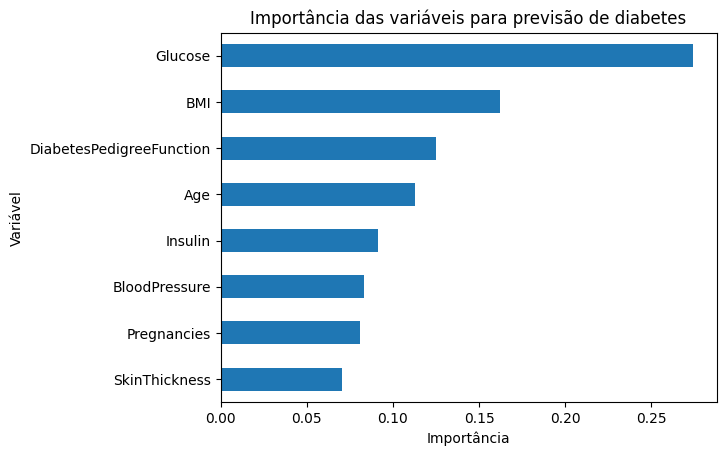

In [13]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns)

importancias.sort_values().plot(kind='barh')
plt.title('Importância das variáveis para previsão de diabetes')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

A análise de importância das variáveis revela que o nível de glicose é, de longe, o fator mais relevante para a previsão de diabetes, indicando forte correlação direta com a presença da doença.

Em seguida, o índice de massa corporal (BMI) também apresenta alta influência, reforçando a relação entre sobrepeso/obesidade e o risco de diabetes.

Variáveis como histórico familiar (DiabetesPedigreeFunction) e idade também demonstram impacto significativo, sugerindo que fatores genéticos e envelhecimento contribuem para o desenvolvimento da condição.

Por outro lado, variáveis como pressão arterial, número de gestações e espessura da pele apresentam menor influência no modelo, indicando que, isoladamente, têm menor poder preditivo.

Do ponto de vista de negócio e saúde, esses resultados sugerem que estratégias de prevenção devem priorizar o controle da glicose e do peso corporal, além de considerar fatores de risco associados ao histórico familiar.

## ⚠️ Limitações do Modelo

Apesar do bom potencial preditivo, o modelo possui limitações:

- O dataset é relativamente pequeno  
- Algumas variáveis apresentam valores originalmente inconsistentes  
- O modelo não substitui avaliação médica  
- Não foi realizado ajuste avançado de hiperparâmetros  
- O projeto possui finalidade educacional e exploratória  

## 🚀 Possíveis Melhorias

Como próximos passos, seria possível:

- Comparar diferentes algoritmos de classificação  
- Realizar ajuste de hiperparâmetros  
- Avaliar recall com mais profundidade  
- Aplicar validação cruzada  
- Testar técnicas de balanceamento de classes  

## 📌 Conclusão

Este projeto demonstrou a aplicação de Machine Learning em um problema relacionado à saúde.

A partir de variáveis clínicas, foi possível construir um modelo inicial para previsão de diabetes e analisar quais fatores tiveram maior influência na classificação.

Os resultados mostram o potencial da análise de dados na área da saúde, especialmente como ferramenta de apoio à identificação de risco.

Como próximos passos, seria possível comparar modelos, melhorar métricas de recall e aprofundar a interpretabilidade.